# Laboratorio numérico de límites

Este cuaderno permite observar aproximaciones por la izquierda y por la derecha. Cambia las listas de distancias o las funciones y ejecuta de nuevo todas las celdas. Las tablas ayudan a formular una conjetura, pero **no sustituyen la justificación algebraica**.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

def tabla_lateral(funcion, a, distancias):
    print(f"{'lado':>10} {'x':>12} {'f(x)':>14}")
    print("-" * 38)
    for lado, signo in (("izquierda", -1), ("derecha", 1)):
        for distancia in distancias:
            x = a + signo * distancia
            print(f"{lado:>10} {x:12.6f} {funcion(x):14.6f}")

## 1. Un agujero no impide que exista el límite

Para $f(x)=(x^2-9)/(x-3)$, la expresión no está definida en $x=3$, pero coincide con $x+3$ cuando $x\ne3$. Observa qué valor sugieren ambos lados.

In [2]:
f_hueco = lambda x: (x**2 - 9) / (x - 3)
distancias = [1, 0.1, 0.01, 0.001]
tabla_lateral(f_hueco, 3, distancias)

      lado            x           f(x)
--------------------------------------
 izquierda     2.000000       5.000000
 izquierda     2.900000       5.900000
 izquierda     2.990000       5.990000
 izquierda     2.999000       5.999000
   derecha     4.000000       7.000000
   derecha     3.100000       6.100000
   derecha     3.010000       6.010000
   derecha     3.001000       6.001000


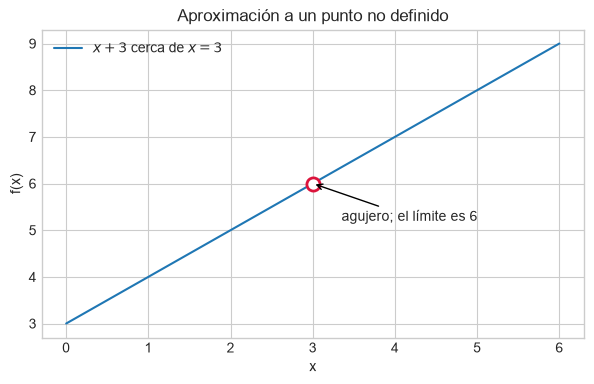

In [3]:
x = np.linspace(0, 6, 400)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, x + 3, label=r"$x+3$ cerca de $x=3$")
ax.scatter([3], [6], s=90, facecolors="white", edgecolors="crimson", linewidth=2, zorder=3)
ax.annotate("agujero; el límite es 6", (3, 6), xytext=(3.35, 5.2), arrowprops={"arrowstyle": "->"})
ax.set(xlabel="x", ylabel="f(x)", title="Aproximación a un punto no definido")
ax.legend()
plt.show()

## 2. Una asíntota tiene comportamientos laterales

Para $g(x)=1/(x-2)$, el signo del denominador cambia al cruzar $2$. Compara la magnitud y el signo de las dos aproximaciones.

In [4]:
g_asintota = lambda x: 1 / (x - 2)
tabla_lateral(g_asintota, 2, distancias)

      lado            x           f(x)
--------------------------------------
 izquierda     1.000000      -1.000000
 izquierda     1.900000     -10.000000
 izquierda     1.990000    -100.000000
 izquierda     1.999000   -1000.000000
   derecha     3.000000       1.000000
   derecha     2.100000      10.000000
   derecha     2.010000     100.000000
   derecha     2.001000    1000.000000


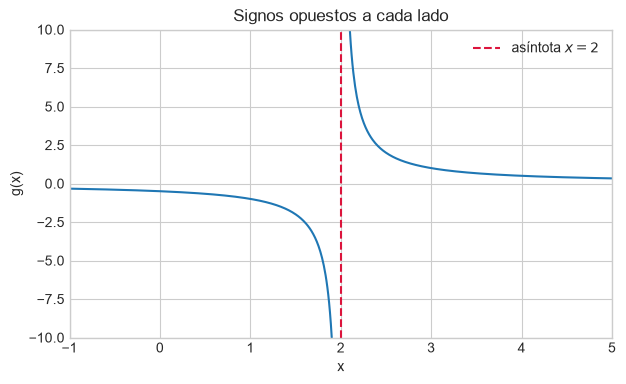

In [5]:
x_izq = np.linspace(-1, 1.9, 300)
x_der = np.linspace(2.1, 5, 300)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x_izq, g_asintota(x_izq), color="tab:blue")
ax.plot(x_der, g_asintota(x_der), color="tab:blue")
ax.axvline(2, color="crimson", linestyle="--", label=r"asíntota $x=2$")
ax.set(xlim=(-1, 5), ylim=(-10, 10), xlabel="x", ylabel="g(x)", title="Signos opuestos a cada lado")
ax.legend()
plt.show()

## 3. Comparar grados en el infinito

Las dos columnas siguientes muestran un cociente de polinomios del mismo grado y otro cuyo denominador tiene mayor grado.

In [6]:
f_mismo_grado = lambda x: (4*x**2 - 3*x + 1) / (2*x**2 + 5*x - 7)
f_grado_menor = lambda x: (3*x + 2) / (x**2 - 1)

print(f"{'x':>8} {'mismo grado':>16} {'grado menor arriba':>20}")
print("-" * 48)
for x in (10, 100, 1_000, 10_000):
    print(f"{x:8d} {f_mismo_grado(x):16.8f} {f_grado_menor(x):20.8f}")

       x      mismo grado   grado menor arriba
------------------------------------------------
      10       1.52674897           0.32323232
     100       1.93729566           0.03020302
    1000       1.99352367           0.00300200
   10000       1.99935024           0.00030002


## Retos para experimentar

1. Añade distancias más pequeñas. ¿Se mantienen las tendencias?
2. Cambia el punto de la asíntota en `g_asintota`. ¿Qué parte de la fórmula debes modificar?
3. Cambia los coeficientes principales de `f_mismo_grado` y predice el nuevo límite antes de ejecutar.
4. Construye una función cuyos límites laterales sean iguales, pero cuyo valor en el punto sea diferente.